# Skin Diagnosis Model - EfficientNet-B3

AI Hub 안면부 피부질환 합성 이미지 데이터를 사용해 EfficientNet-B3 기반 피부진단 이미지 분류 모델을 학습하고 평가합니다.

- Train/Validation split source: `D:/ai_hub_data/14.안면부 피부질환 이미지 합성데이터/3.개방데이터/1.데이터/Training`
- Final test: `D:/ai_hub_data/14.안면부 피부질환 이미지 합성데이터/3.개방데이터/1.데이터/Validation`
- Max epochs: 50
- Progressive unfreeze: 4 stages
- EarlyStopping: Stage 4 이후부터 validation loss 기준 적용, patience 8
- 평가: 정확도, 혼동행렬, 성공/실패 사례 각 4개

## 0. Environment

터미널에서 아래 환경을 활성화한 뒤 이 노트북을 실행합니다.

```bash
conda activate skin_vlm
jupyter notebook
```

In [1]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda')

## 0-1. Matplotlib Korean Font

Windows/Jupyter에서 혼동행렬 등 그래프의 한글 라벨이 깨지지 않도록 한글 폰트를 설정합니다.


In [ ]:
import matplotlib.font_manager as fm


def set_korean_matplotlib_font():
    candidate_fonts = ['Malgun Gothic', 'NanumGothic', 'AppleGothic']
    installed_fonts = {font.name for font in fm.fontManager.ttflist}

    for font_name in candidate_fonts:
        if font_name in installed_fonts:
            plt.rcParams['font.family'] = font_name
            plt.rcParams['axes.unicode_minus'] = False
            print(f'Matplotlib Korean font: {font_name}')
            return font_name

    plt.rcParams['axes.unicode_minus'] = False
    print('Korean font not found. Install Malgun Gothic or NanumGothic if labels are broken.')
    return None


set_korean_matplotlib_font()


## 1. Configuration

In [2]:
PROJECT_DIR = Path(r'D:/vibe_coding/codex/Skin_Project/Skin_diagnosis2')
TRAIN_ROOT = Path(r'D:/ai_hub_data/14.안면부 피부질환 이미지 합성데이터/3.개방데이터/1.데이터/Training/01.원천데이터')
TEST_ROOT = Path(r'D:/ai_hub_data/14.안면부 피부질환 이미지 합성데이터/3.개방데이터/1.데이터/Validation/01.원천데이터')

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
IMG_SIZE = 300
BATCH_SIZE = 16
NUM_WORKERS = 0  # Windows/Jupyter 환경에서는 0이 가장 안정적입니다.
MAX_EPOCHS = 50
VAL_RATIO = 0.2
EARLY_STOPPING_PATIENCE = 8

CHECKPOINT_PATH = PROJECT_DIR / 'best_efficientnet_b3_skin_diagnosis.pt'
LAST_MODEL_PATH = PROJECT_DIR / 'last_efficientnet_b3_skin_diagnosis.pt'

STAGES = [
    {'name': 'Stage 1 - classifier only', 'start': 1, 'end': 5, 'unfreeze_ratio': 0.00, 'backbone_lr': 0.0, 'head_lr': 1e-4, 'early_stop': False},
    {'name': 'Stage 2 - top 25%', 'start': 6, 'end': 12, 'unfreeze_ratio': 0.25, 'backbone_lr': 1e-5, 'head_lr': 1e-4, 'early_stop': False},
    {'name': 'Stage 3 - top 50%', 'start': 13, 'end': 20, 'unfreeze_ratio': 0.50, 'backbone_lr': 7e-6, 'head_lr': 7e-5, 'early_stop': False},
    {'name': 'Stage 4 - top 75%', 'start': 21, 'end': 50, 'unfreeze_ratio': 0.75, 'backbone_lr': 5e-6, 'head_lr': 5e-5, 'early_stop': True},
]

print(f'Device: {DEVICE}')
print(f'Train root exists: {TRAIN_ROOT.exists()}')
print(f'Test root exists: {TEST_ROOT.exists()}')
print(f'Validation ratio from Training data: {VAL_RATIO:.0%}')

Device: cuda
Train root exists: True
Test root exists: True
Validation ratio from Training data: 20%


## 2. Dataset Loading

폴더명 예시 `TS_건선_정면`, `VS_여드름_측면`에서 가운데 질환명을 클래스 라벨로 사용합니다.

`Training` 폴더는 stratified 방식으로 학습/검증으로 나눕니다. `Validation` 폴더는 최종 테스트 전용으로만 사용합니다.

In [3]:
def extract_label_from_folder(folder_name: str) -> str:
    parts = folder_name.split('_')
    if len(parts) >= 2:
        return parts[1]
    return folder_name


def collect_samples(root: Path):
    samples = []
    for class_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
        label = extract_label_from_folder(class_dir.name)
        for image_path in class_dir.rglob('*'):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                samples.append((image_path, label))
    return samples


all_train_samples = collect_samples(TRAIN_ROOT)
test_samples = collect_samples(TEST_ROOT)

classes = sorted(set([label for _, label in all_train_samples]))
class_to_idx = {class_name: idx for idx, class_name in enumerate(classes)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}


def stratified_train_val_split(samples, val_ratio=0.2, seed=42):
    rng = random.Random(seed)
    grouped = {}
    for image_path, label in samples:
        grouped.setdefault(label, []).append((image_path, label))

    train_split = []
    val_split = []
    for label, label_samples in grouped.items():
        label_samples = label_samples.copy()
        rng.shuffle(label_samples)
        val_count = int(round(len(label_samples) * val_ratio))
        val_split.extend(label_samples[:val_count])
        train_split.extend(label_samples[val_count:])

    rng.shuffle(train_split)
    rng.shuffle(val_split)
    return train_split, val_split


train_samples, val_samples = stratified_train_val_split(all_train_samples, VAL_RATIO, SEED)

print(f'Train images: {len(train_samples):,}')
print(f'Validation images: {len(val_samples):,}')
print(f'Test images: {len(test_samples):,}')
print(f'Classes: {classes}')
print('Train distribution:', Counter([label for _, label in train_samples]))
print('Validation distribution:', Counter([label for _, label in val_samples]))
print('Test distribution:', Counter([label for _, label in test_samples]))

Train images: 7,680
Validation images: 1,920
Test images: 1,200
Classes: ['건선', '아토피', '여드름', '정상', '주사', '지루']
Train distribution: Counter({'아토피': 1280, '정상': 1280, '지루': 1280, '건선': 1280, '여드름': 1280, '주사': 1280})
Validation distribution: Counter({'건선': 320, '아토피': 320, '정상': 320, '주사': 320, '여드름': 320, '지루': 320})
Test distribution: Counter({'건선': 200, '아토피': 200, '여드름': 200, '정상': 200, '주사': 200, '지루': 200})


In [4]:
class SkinDiseaseDataset(Dataset):
    def __init__(self, samples, class_to_idx, transform=None):
        self.samples = samples
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label_name = self.samples[idx]
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.class_to_idx[label_name]
        return image, label, str(image_path)


weights = EfficientNet_B3_Weights.IMAGENET1K_V1
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = SkinDiseaseDataset(train_samples, class_to_idx, train_transform)
val_dataset = SkinDiseaseDataset(val_samples, class_to_idx, test_transform)
test_dataset = SkinDiseaseDataset(test_samples, class_to_idx, test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

len(train_loader), len(val_loader), len(test_loader)

(480, 120, 75)

## 3. Model

In [5]:
def build_model(num_classes: int):
    model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def set_trainable_layers(model: nn.Module, unfreeze_ratio: float):
    for param in model.parameters():
        param.requires_grad = False

    feature_blocks = list(model.features.children())
    num_blocks = len(feature_blocks)
    num_unfreeze = int(round(num_blocks * unfreeze_ratio))
    if num_unfreeze > 0:
        for block in feature_blocks[-num_unfreeze:]:
            for param in block.parameters():
                param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f'Unfreeze ratio: {unfreeze_ratio:.0%} | trainable params: {trainable:,} / {total:,} ({trainable / total:.2%})')


def make_optimizer(model: nn.Module, backbone_lr: float, head_lr: float):
    backbone_params = [p for name, p in model.named_parameters() if p.requires_grad and not name.startswith('classifier')]
    head_params = [p for name, p in model.named_parameters() if p.requires_grad and name.startswith('classifier')]
    param_groups = []
    if backbone_params and backbone_lr > 0:
        param_groups.append({'params': backbone_params, 'lr': backbone_lr})
    if head_params:
        param_groups.append({'params': head_params, 'lr': head_lr})
    return torch.optim.AdamW(param_groups, weight_decay=1e-4)


model = build_model(num_classes=len(classes)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

## 4. Training

Stage 1-3은 20 epoch까지 무조건 진행합니다. EarlyStopping은 Stage 4가 시작되는 21 epoch부터 validation loss 기준으로만 적용합니다. Test set은 학습 루프 안에서 사용하지 않습니다.

In [6]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels, _ in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = float(np.mean(np.array(all_labels) == np.array(all_preds)))
    return avg_loss, accuracy


def get_stage(epoch: int):
    for stage in STAGES:
        if stage['start'] <= epoch <= stage['end']:
            return stage
    raise ValueError(f'No stage configured for epoch {epoch}')


history = []
best_val_loss = float('inf')
early_stop_counter = 0
current_stage_name = None
optimizer = None

for epoch in range(1, MAX_EPOCHS + 1):
    stage = get_stage(epoch)

    if stage['name'] != current_stage_name:
        print(f"\n==> {stage['name']} | epochs {stage['start']}-{stage['end']}")
        set_trainable_layers(model, stage['unfreeze_ratio'])
        optimizer = make_optimizer(model, stage['backbone_lr'], stage['head_lr'])
        current_stage_name = stage['name']

    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_one_epoch(model, val_loader, criterion, optimizer=None)

    row = {
        'epoch': epoch,
        'stage': stage['name'],
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
    }
    history.append(row)
    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_to_idx': class_to_idx,
            'idx_to_class': idx_to_class,
            'epoch': epoch,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'stage': stage['name'],
        }, CHECKPOINT_PATH)
        print(f'  Saved best checkpoint: {CHECKPOINT_PATH}')
    elif stage['early_stop']:
        early_stop_counter += 1
        print(f'  EarlyStopping counter: {early_stop_counter}/{EARLY_STOPPING_PATIENCE}')

    if stage['early_stop'] and early_stop_counter >= EARLY_STOPPING_PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

torch.save({'model_state_dict': model.state_dict(), 'class_to_idx': class_to_idx, 'idx_to_class': idx_to_class}, LAST_MODEL_PATH)
history_df = pd.DataFrame(history)
history_df.tail()


==> Stage 1 - classifier only | epochs 1-5
Unfreeze ratio: 0% | trainable params: 9,222 / 10,705,454 (0.09%)
Epoch 01/50 | train_loss=1.5913 train_acc=0.4646 | val_loss=1.4248 val_acc=0.6250
  Saved best checkpoint: D:\vibe_coding\codex\Skin_Project\Skin_diagnosis2\best_efficientnet_b3_skin_diagnosis.pt
Epoch 02/50 | train_loss=1.3024 train_acc=0.6514 | val_loss=1.1954 val_acc=0.7036
  Saved best checkpoint: D:\vibe_coding\codex\Skin_Project\Skin_diagnosis2\best_efficientnet_b3_skin_diagnosis.pt
Epoch 03/50 | train_loss=1.1312 train_acc=0.6957 | val_loss=1.0711 val_acc=0.7120
  Saved best checkpoint: D:\vibe_coding\codex\Skin_Project\Skin_diagnosis2\best_efficientnet_b3_skin_diagnosis.pt
Epoch 04/50 | train_loss=1.0228 train_acc=0.7064 | val_loss=0.9678 val_acc=0.7375
  Saved best checkpoint: D:\vibe_coding\codex\Skin_Project\Skin_diagnosis2\best_efficientnet_b3_skin_diagnosis.pt
Epoch 05/50 | train_loss=0.9526 train_acc=0.7207 | val_loss=0.9197 val_acc=0.7302
  Saved best checkpoint:

,epoch,stage,train_loss,train_acc,val_loss,val_acc
45,46,Stage 4 - top 75%,0.110310,0.965104,0.203247,0.932813
46,47,Stage 4 - top 75%,0.101775,0.966927,0.200654,0.934896
47,48,Stage 4 - top 75%,0.103571,0.964583,0.203850,0.935417
48,49,Stage 4 - top 75%,0.101311,0.965234,0.204543,0.929167
49,50,Stage 4 - top 75%,0.103316,0.963281,0.205975,0.933333


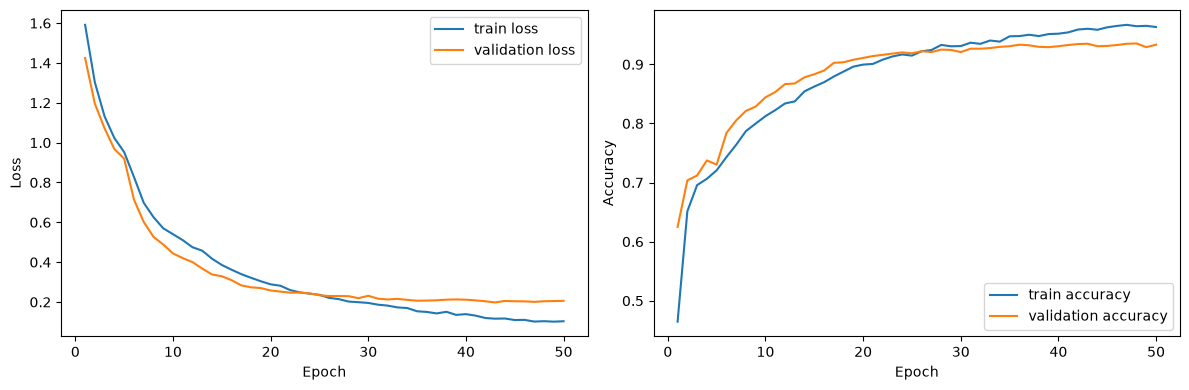

In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], label='train loss')
plt.plot(history_df['epoch'], history_df['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['train_acc'], label='train accuracy')
plt.plot(history_df['epoch'], history_df['val_acc'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Evaluation

In [8]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_labels = []
all_preds = []
all_probs = []
all_paths = []

with torch.no_grad():
    for images, labels, paths in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(paths)

def make_confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true_idx, pred_idx in zip(y_true, y_pred):
        cm[int(true_idx), int(pred_idx)] += 1
    return cm


def make_classification_report(y_true, y_pred, classes):
    cm = make_confusion_matrix(y_true, y_pred, len(classes))
    rows = []
    for idx, class_name in enumerate(classes):
        tp = cm[idx, idx]
        fp = cm[:, idx].sum() - tp
        fn = cm[idx, :].sum() - tp
        support = cm[idx, :].sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        rows.append({'class': class_name, 'precision': precision, 'recall': recall, 'f1-score': f1, 'support': int(support)})
    return pd.DataFrame(rows)


test_accuracy = float(np.mean(np.array(all_labels) == np.array(all_preds)))
print(f'Test Accuracy: {test_accuracy:.4f}')
print('\nClassification Report')
display(make_classification_report(all_labels, all_preds, classes))

C:\Users\hugctx\AppData\Local\Temp\ipykernel_36080\3658051820.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVIC

Test Accuracy: 0.8883

Classification Report


,class,precision,recall,f1-score,support
0,건선,0.873786,0.900,0.886700,200
1,아토피,0.891626,0.905,0.898263,200
2,여드름,0.921348,0.820,0.867725,200
3,정상,1.000000,1.000,1.000000,200
4,주사,0.927778,0.835,0.878947,200
5,지루,0.746781,0.870,0.803695,200


### 5-1. 정확도

In [13]:
print(f'정확도(Accuracy): {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)')

정확도(Accuracy): 0.8883 (88.83%)


### 5-2. 혼동행렬

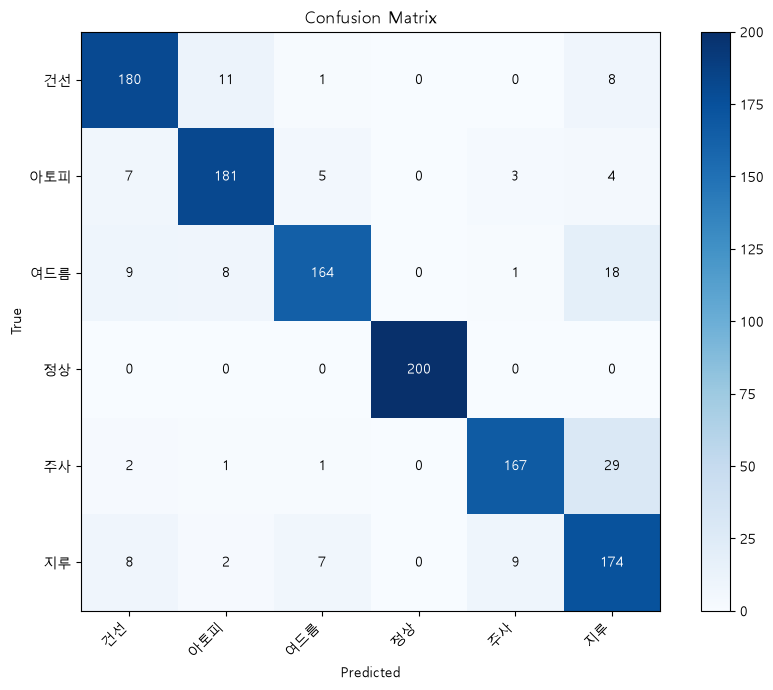

In [14]:
cm = make_confusion_matrix(all_labels, all_preds, len(classes))
plt.figure(figsize=(9, 7))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha='right')
plt.yticks(tick_marks, classes)
threshold = cm.max() / 2 if cm.max() > 0 else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color='white' if cm[i, j] > threshold else 'black')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### 5-3. 성공/실패 사례 각 4개

### 5-4. View-wise Accuracy Analysis

테스트셋 폴더명(`VS_질환_정면`, `VS_질환_측면`)에서 촬영 방향을 추출해 정면/측면별 정확도와 오답 신뢰도를 분석합니다.


In [17]:
def extract_view_from_path(path):
    folder_name = Path(path).parent.name
    parts = folder_name.split('_')
    if len(parts) >= 3:
        return parts[2]
    if '정면' in folder_name:
        return '정면'
    if '측면' in folder_name:
        return '측면'
    return 'unknown'


results_df['view'] = results_df['path'].apply(extract_view_from_path)
results_df['margin'] = [
    float(np.sort(prob)[-1] - np.sort(prob)[-2]) if len(prob) >= 2 else np.nan
    for prob in all_probs
]

view_summary = (
    results_df
    .groupby('view')
    .agg(
        samples=('correct', 'size'),
        accuracy=('correct', 'mean'),
        mean_confidence=('confidence', 'mean'),
        wrong_count=('correct', lambda x: int((~x).sum())),
    )
    .reset_index()
)
display(view_summary)

class_view_summary = (
    results_df
    .groupby(['true_label', 'view'])
    .agg(
        samples=('correct', 'size'),
        accuracy=('correct', 'mean'),
        mean_confidence=('confidence', 'mean'),
        wrong_count=('correct', lambda x: int((~x).sum())),
    )
    .reset_index()
    .sort_values(['true_label', 'view'])
)
display(class_view_summary)

wrong_confidence_summary = (
    results_df[~results_df['correct']]
    .groupby(['true_label', 'pred_label', 'view'])
    .agg(
        errors=('correct', 'size'),
        mean_confidence=('confidence', 'mean'),
        max_confidence=('confidence', 'max'),
        mean_margin=('margin', 'mean'),
    )
    .reset_index()
    .sort_values(['errors', 'mean_confidence'], ascending=False)
)
display(wrong_confidence_summary.head(20))

print('High-confidence wrong predictions')
display(
    results_df[~results_df['correct']]
    .sort_values('confidence', ascending=False)
    [['path', 'view', 'true_label', 'pred_label', 'confidence', 'margin']]
    .head(20)
)


,view,samples,accuracy,mean_confidence,wrong_count
0,정면,600,0.781667,0.873576,131
1,측면,600,0.995000,0.991714,3


,true_label,view,samples,accuracy,mean_confidence,wrong_count
0,건선,정면,100,0.81,0.896736,19
1,건선,측면,100,0.99,0.989125,1
2,아토피,정면,100,0.83,0.870737,17
3,아토피,측면,100,0.98,0.972796,2
4,여드름,정면,100,0.64,0.839874,36
5,여드름,측면,100,1.00,0.999343,0
6,정상,정면,100,1.00,0.988567,0
7,정상,측면,100,1.00,0.996941,0
8,주사,정면,100,0.67,0.854433,33
9,주사,측면,100,1.00,0.997699,0


,true_label,pred_label,view,errors,mean_confidence,max_confidence,mean_margin
16,주사,지루,정면,29,0.803981,0.995934,0.636096
12,여드름,지루,정면,18,0.719593,0.977268,0.519290
0,건선,아토피,정면,10,0.733509,0.986115,0.514132
20,지루,주사,정면,9,0.761689,0.989839,0.562003
9,여드름,건선,정면,9,0.702484,0.995897,0.485272
3,건선,지루,정면,8,0.776301,0.989335,0.612208
10,여드름,아토피,정면,8,0.753570,0.934870,0.594798
17,지루,건선,정면,8,0.723393,0.991996,0.519511
19,지루,여드름,정면,7,0.685426,0.994503,0.450774
6,아토피,여드름,정면,5,0.836458,0.980562,0.698915


High-confidence wrong predictions


,path,view,true_label,pred_label,confidence,margin
878,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,정면,주사,지루,0.995934,0.993871
462,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,정면,여드름,건선,0.995897,0.993820
1028,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,정면,지루,여드름,0.994503,0.990821
825,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,정면,주사,지루,0.992158,0.987018
1014,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,정면,지루,건선,0.991996,0.984035
1029,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,정면,지루,주사,0.989839,0.983209
850,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,정면,주사,지루,0.989598,0.982811
16,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,정면,건선,지루,0.989335,0.985110
55,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,정면,건선,아토피,0.986115,0.972485
813,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,정면,주사,지루,0.985412,0.971107


In [15]:
results_df = pd.DataFrame({
    'path': all_paths,
    'true_idx': all_labels,
    'pred_idx': all_preds,
})
results_df['true_label'] = results_df['true_idx'].map(idx_to_class)
results_df['pred_label'] = results_df['pred_idx'].map(idx_to_class)
results_df['confidence'] = [float(np.max(prob)) for prob in all_probs]
results_df['correct'] = results_df['true_idx'] == results_df['pred_idx']

success_examples = results_df[results_df['correct']].sort_values('confidence', ascending=False).head(4)
failure_examples = results_df[~results_df['correct']].sort_values('confidence', ascending=False).head(4)

print('Success examples')
display(success_examples[['path', 'true_label', 'pred_label', 'confidence']])
print('Failure examples')
display(failure_examples[['path', 'true_label', 'pred_label', 'confidence']])

Success examples


,path,true_label,pred_label,confidence
528,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,여드름,여드름,0.999999
557,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,여드름,여드름,0.999999
590,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,여드름,여드름,0.999999
914,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,주사,주사,0.999999


Failure examples


,path,true_label,pred_label,confidence
878,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,주사,지루,0.995934
462,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,여드름,건선,0.995897
1028,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,지루,여드름,0.994503
825,D:\ai_hub_data\14.안면부 피부질환 이미지 합성데이터\3.개방데이터\1...,주사,지루,0.992158


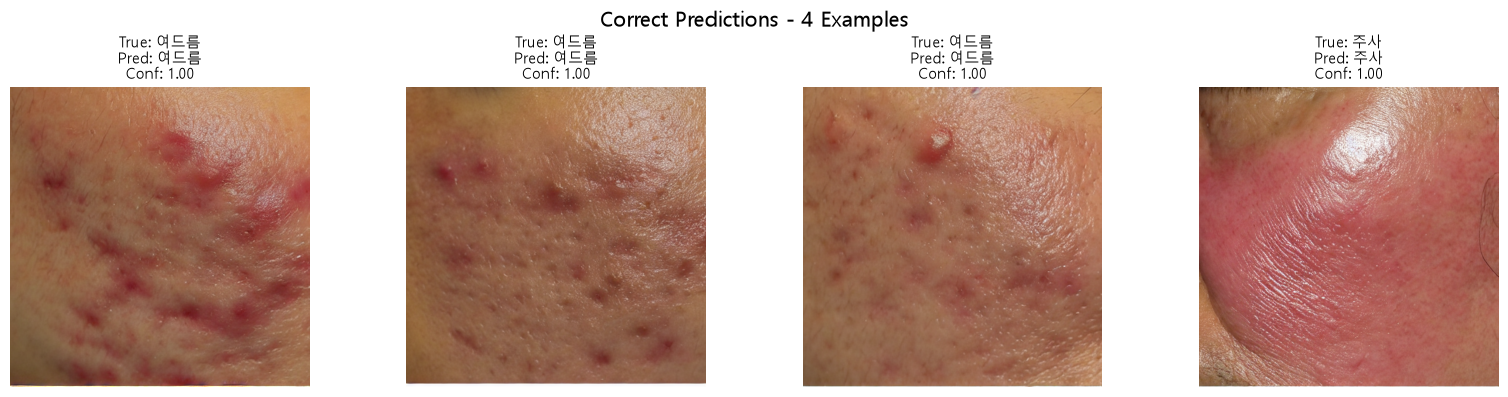

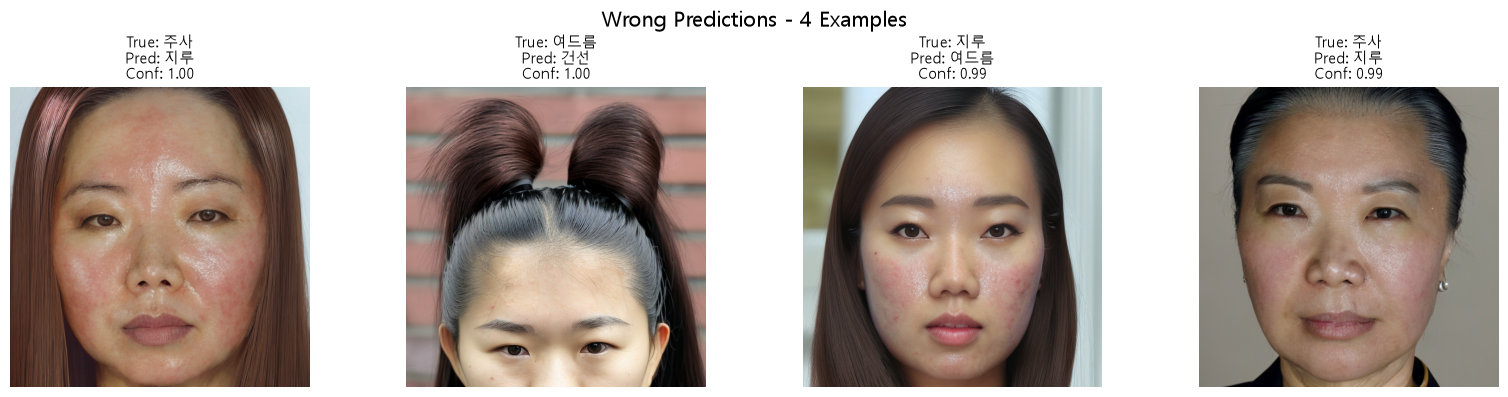

In [16]:
def show_examples(examples_df, title):
    if len(examples_df) == 0:
        print(f'No examples for: {title}')
        return

    n = len(examples_df)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, examples_df.iterrows()):
        image = Image.open(row['path']).convert('RGB')
        ax.imshow(image)
        ax.axis('off')
        ax.set_title(
            f"True: {row['true_label']}\nPred: {row['pred_label']}\nConf: {row['confidence']:.2f}",
            fontsize=11,
        )
    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()


show_examples(success_examples, 'Correct Predictions - 4 Examples')
show_examples(failure_examples, 'Wrong Predictions - 4 Examples')